In [1]:
import numpy as np
from pathlib import Path
import gamry_parser
from scipy.optimize import differential_evolution
from impedance.models.circuits import CustomCircuit
import matplotlib.pyplot as plt


In [2]:
data_folder = Path(r'C:\Users\Alexa\Desktop\PEA\EIS_data\BTA')
filename = 'Cauvel_3_BTA_1H.dta'
file_to_open = data_folder / filename
parser = gamry_parser.GamryParser()
parser.load(filename = str(file_to_open))
data = parser.curves[0]
eis_data = {
        'name':str(filename).split("\\")[-1],
        'Zreal':data['Zreal'].values,
        'Zimag':-data['Zimag'].values,
        'Zmod':data['Zmod'].values,
        'Zphz':data['Zphz'].values,
        'Freq':data['Freq'].values,
        'Z_data': data['Zreal'].values + 1j*data['Zimag'].values
}z

In [19]:
circuit_string = 'R0-p(R4-p(CPE1, R1-p(CPE2, R2)-p(L3,R3)),CPE4)'
#R0, R4, CPE1_Q, CPE1_n, R1, CPE2_Q, CPE2_n, R2, L3, R3, CPE4_Q, CPE4_n
bounds = [(1e-3, 1e2), 
          (1, 1e7), 
          (1e-9, 1e-3), 
          (0.5,1), 
          (1, 1e7), 
          (1e-9,1e-3), 
          (0.5,1), 
          (1, 1e7), 
          (1, 1e7), 
          (1e-1, 1e7), 
          (1e-9,1e-3), 
          (0.5,1)]

In [20]:
def objective_function(params):
    try:
        circuit = CustomCircuit(circuit_string, initial_guess=params)
        Z_fit = circuit.predict(eis_data['Freq'])
        res = np.sum(np.abs(eis_data['Z_data'] - Z_fit)**2/np.abs(eis_data['Z_data'])**2)
        return res
    except:
        return 1e15

In [21]:
result = differential_evolution(
    objective_function, 
    bounds,
    strategy='best1bin',
    popsize=100,
    tol=0.001,
    mutation=(0.5, 1),
    recombination=0.7
)
print(f"Best parameters found: {result.x}")
frequencies = eis_data['Freq']
final_params = result.x
final_circuit = CustomCircuit(circuit_string, initial_guess=final_params)

# 3. Predict the Z values (this creates the 'Z_fit' line)
Z_fit= final_circuit.predict(frequencies)

Best parameters found: [7.47069838e+01 2.94958495e+02 2.79676960e-06 8.98600618e-01
 3.02750025e+04 8.05507665e-04 8.77465807e-01 1.64793803e+01
 1.85205506e+05 4.57861926e+04 7.38872426e-06 9.20004351e-01]


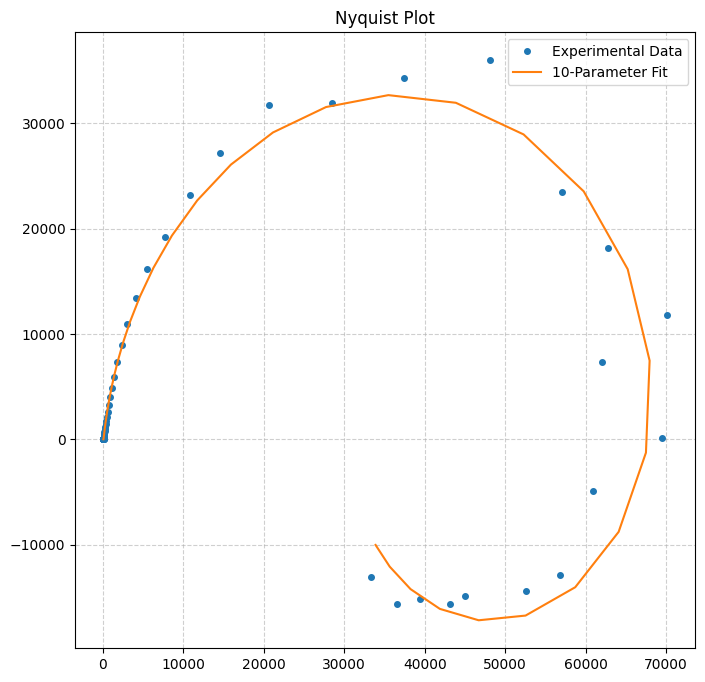

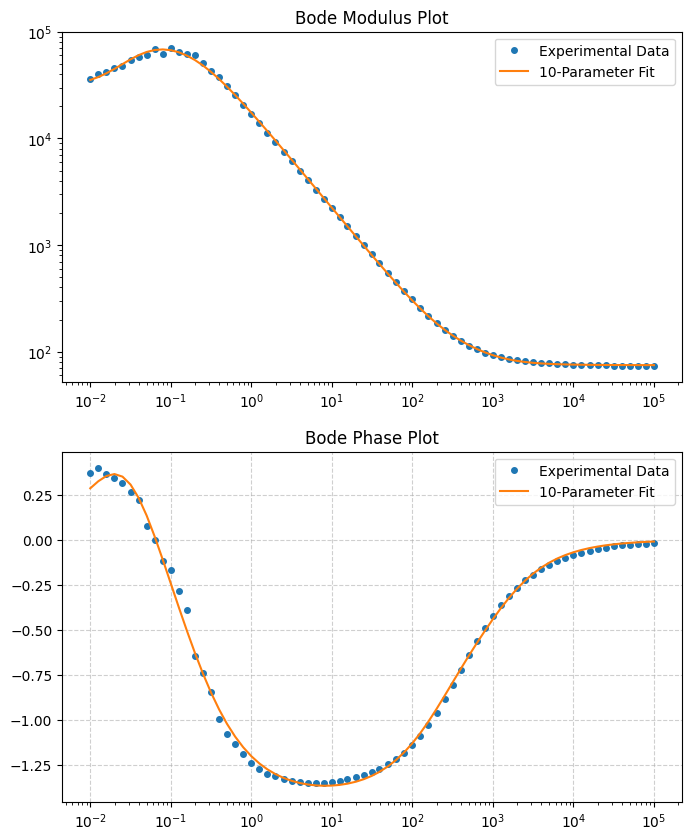


--- Optimized Circuit Parameters ---

Circuit string: R0-p(R4-p(CPE1,R1-p(CPE2,R2)-p(L3,R3)),CPE4)
Fit: False

Initial guesses:
     R0 = 7.47e+01 [Ohm]
     R4 = 2.95e+02 [Ohm]
  CPE1_0 = 2.80e-06 [Ohm^-1 sec^a]
  CPE1_1 = 8.99e-01 []
     R1 = 3.03e+04 [Ohm]
  CPE2_0 = 8.06e-04 [Ohm^-1 sec^a]
  CPE2_1 = 8.77e-01 []
     R2 = 1.65e+01 [Ohm]
     L3 = 1.85e+05 [H]
     R3 = 4.58e+04 [Ohm]
  CPE4_0 = 7.39e-06 [Ohm^-1 sec^a]
  CPE4_1 = 9.20e-01 []



In [22]:
plt.figure(figsize=(8, 8))

plt.plot(eis_data['Z_data'].real, -eis_data['Z_data'].imag, 'o', label='Experimental Data', markersize=4)
plt.plot(Z_fit.real, -Z_fit.imag, '-', label='10-Parameter Fit')
plt.legend()
plt.title("Nyquist Plot")

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

fig, (ax2,ax3) = plt.subplots(2, 1, figsize=(8, 10)) 
ax2.loglog(eis_data['Freq'], abs(eis_data['Z_data']), 'o', label='Experimental Data', markersize=4)
ax2.loglog(eis_data['Freq'], abs(Z_fit), '-', label='10-Parameter Fit')
ax2.legend()
ax2.set_title("Bode Modulus Plot")

ax3.semilogx(eis_data['Freq'], np.angle(eis_data['Z_data']), 'o', label='Experimental Data', markersize=4)
ax3.semilogx(eis_data['Freq'], np.angle(Z_fit), '-', label='10-Parameter Fit')
ax3.legend()
ax3.set_title("Bode Phase Plot")

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n--- Optimized Circuit Parameters ---")
print(final_circuit)

In [25]:
def calculate_chi_squared(z_data, z_fit, n_params):
    n_points = len(eis_data['Z_data'])
    degrees_of_freedom = n_points - n_params
    
    weight = np.abs(eis_data['Z_data'])**2
    residuals = (np.abs(eis_data['Z_data'] - Z_fit)**2) / weight
    
    chi_sq = np.sum(residuals) / degrees_of_freedom
    return chi_sq

chi_result = calculate_chi_squared(eis_data['Z_data'], Z_fit, 10)
print(f"Reduced Chi-Squared: {chi_result:.2e}")

mape = np.mean(np.abs((eis_data['Z_data'] - Z_fit) / eis_data['Z_data'])) * 100
print(f"MAPE: {mape:.2f}%")

errors = circuit.stdev_

for name, val, err in zip(circuit.parameters_, circuit.parameters, errors):
    percent_error = (err / val) * 100
    print(f"{name}: {val:.2e} ± {percent_error:.2f}%")

Reduced Chi-Squared: 2.06e-03
MAPE: 3.42%


NameError: name 'circuit' is not defined